# Diabetes Prediction using Machine Learning




In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import Libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset

This notebook uses the **Pima Indians Diabetes Dataset** loaded from `diabetes.csv`.

If you're running this in Google Colab, upload `diabetes.csv` to the Colab file browser (left sidebar → folder icon → upload) so the path below can find it, or mount your Google Drive.


In [19]:
# If running in Colab and the file isn't found, uncomment the lines below to upload it manually:
# from google.colab import files
# uploaded = files.upload()
import pandas as pd

df = pd.read_csv('/diabetes.csv')

print("Total patients:", len(df))
print("Diabetic patients:", (df['Outcome'] == 1).sum())
print("Non-diabetic patients:", (df['Outcome'] == 0).sum())
print("Missing values:", df.isnull().sum().sum())

df.head()


Total patients: 768
Diabetic patients: 268
Non-diabetic patients: 500
Missing values: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Exploratory Data Analysis (EDA)


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [21]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome
0    500
1    268
Name: count, dtype: int64


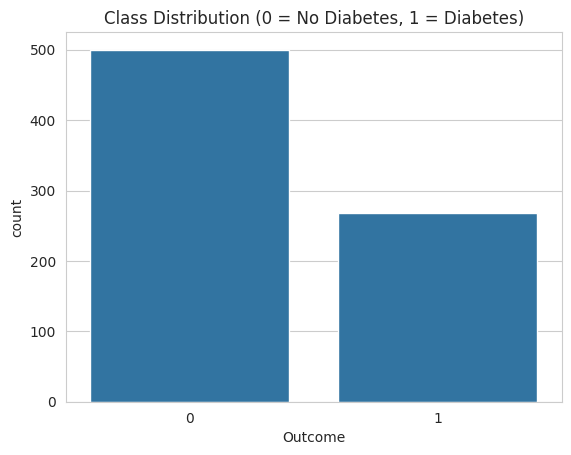

In [22]:
# Check target class balance
print(df['Outcome'].value_counts())
sns.countplot(x='Outcome', data=df)
plt.title('Class Distribution (0 = No Diabetes, 1 = Diabetes)')
plt.show()


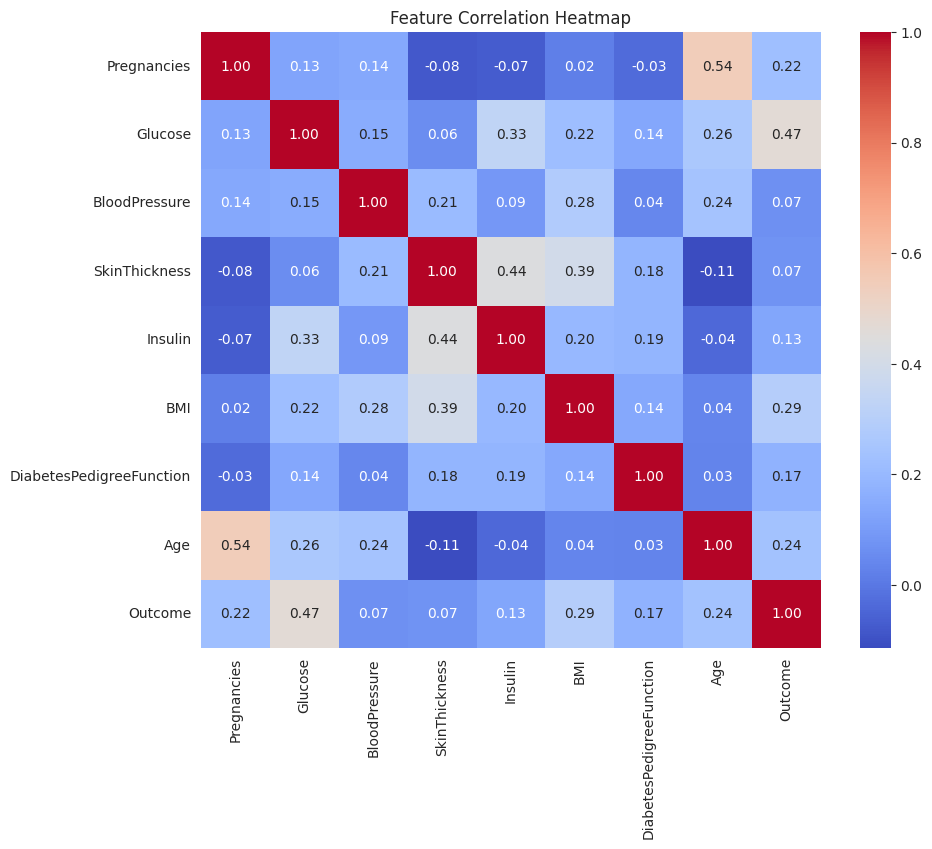

In [24]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


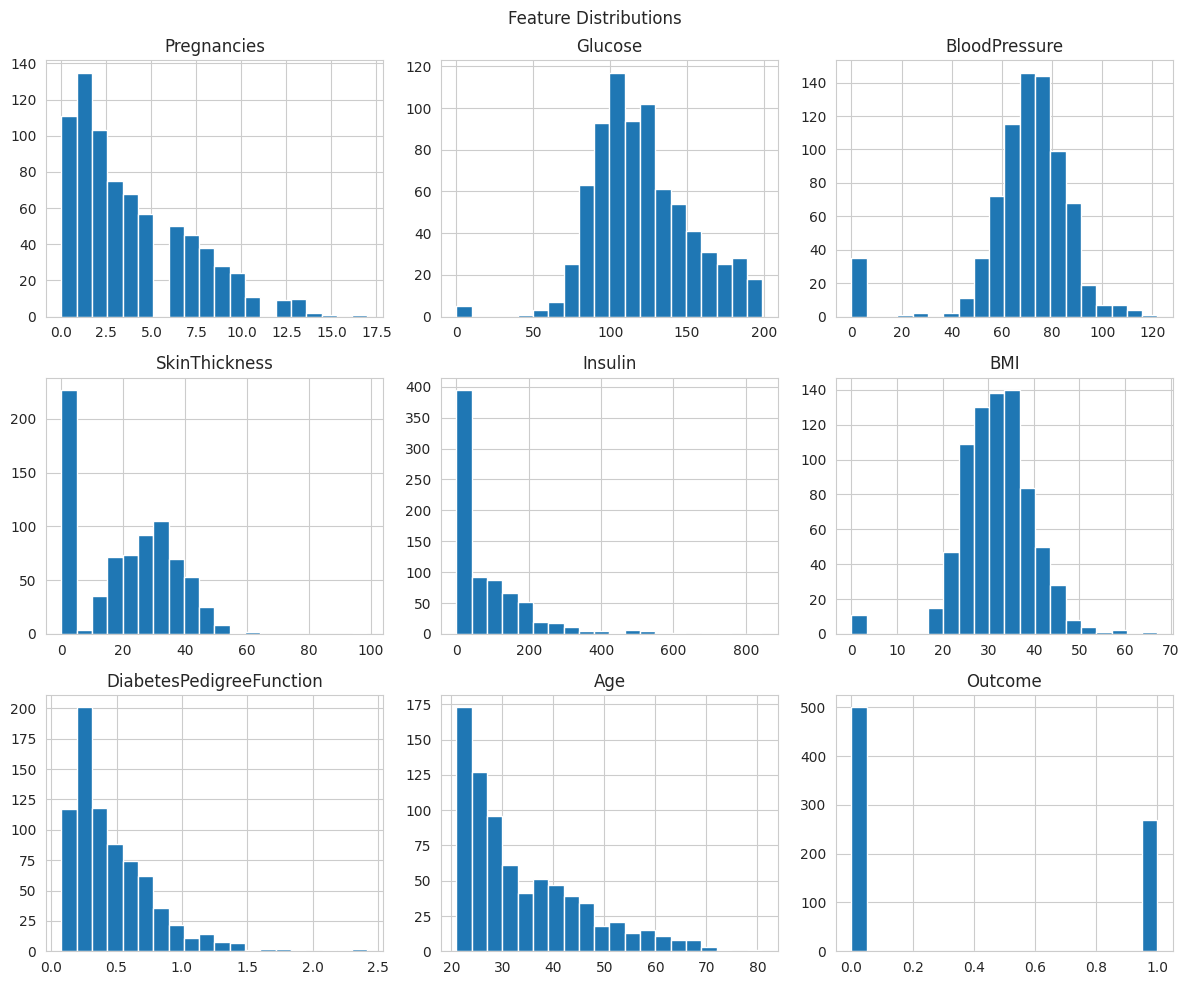

In [27]:
# Distribution of each feature
df.hist(figsize=(12, 10), bins=20)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()


### 3.1 Outlier Detection


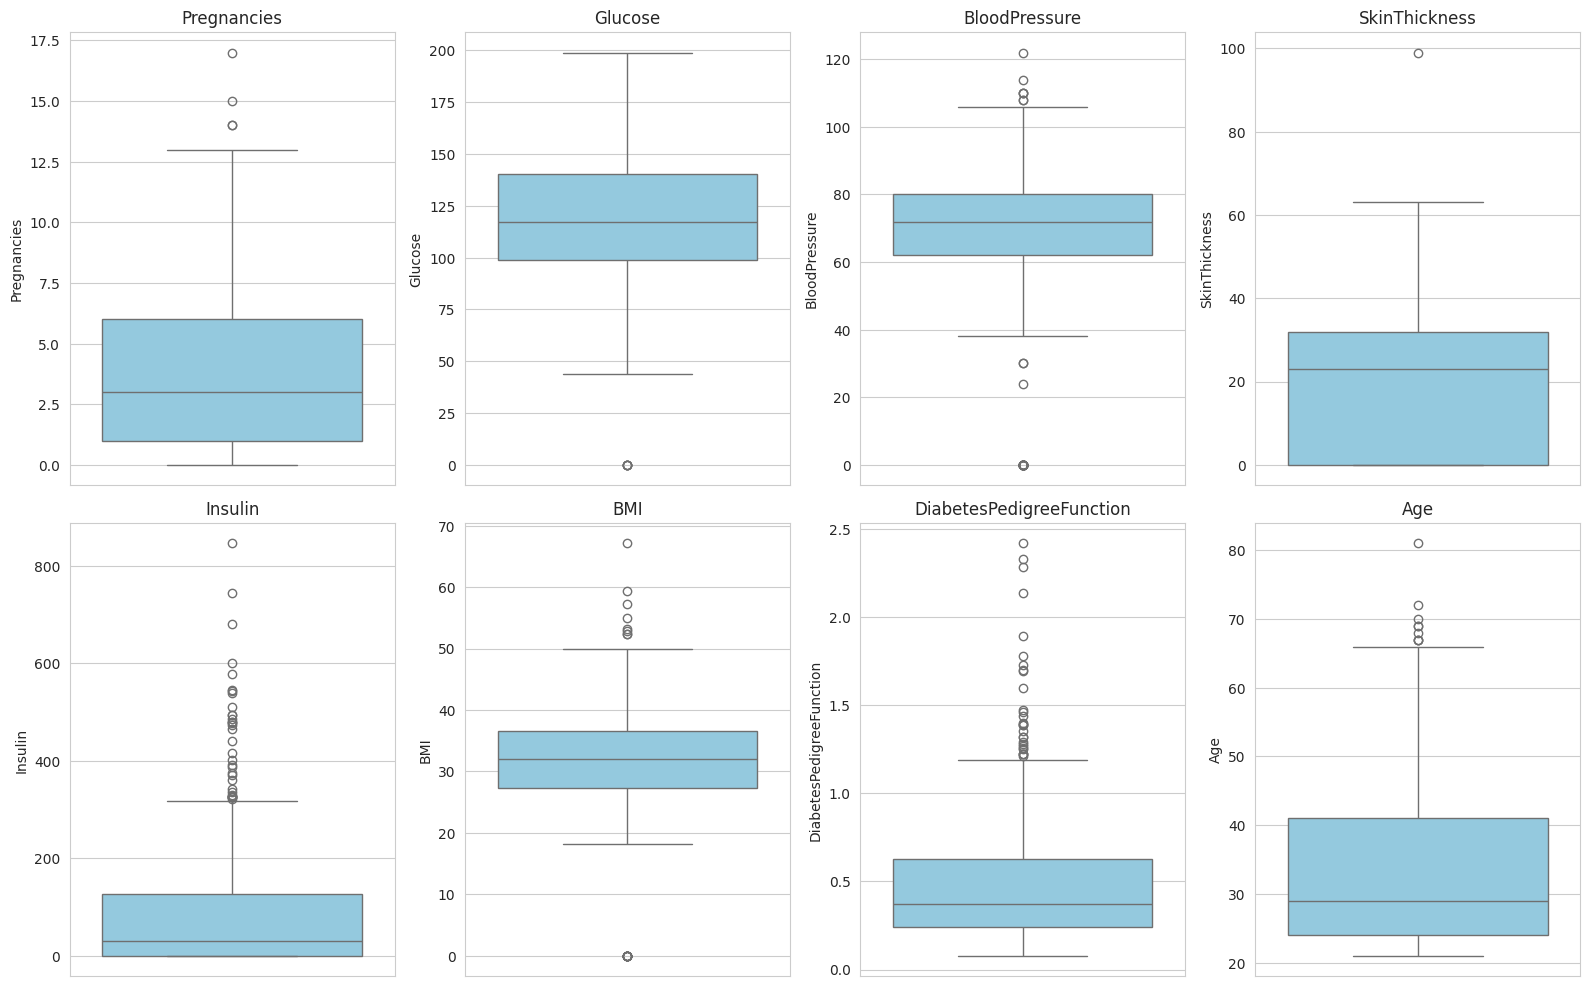

In [33]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()


### 3.2 Pairplot (Feature Relationships by Outcome)


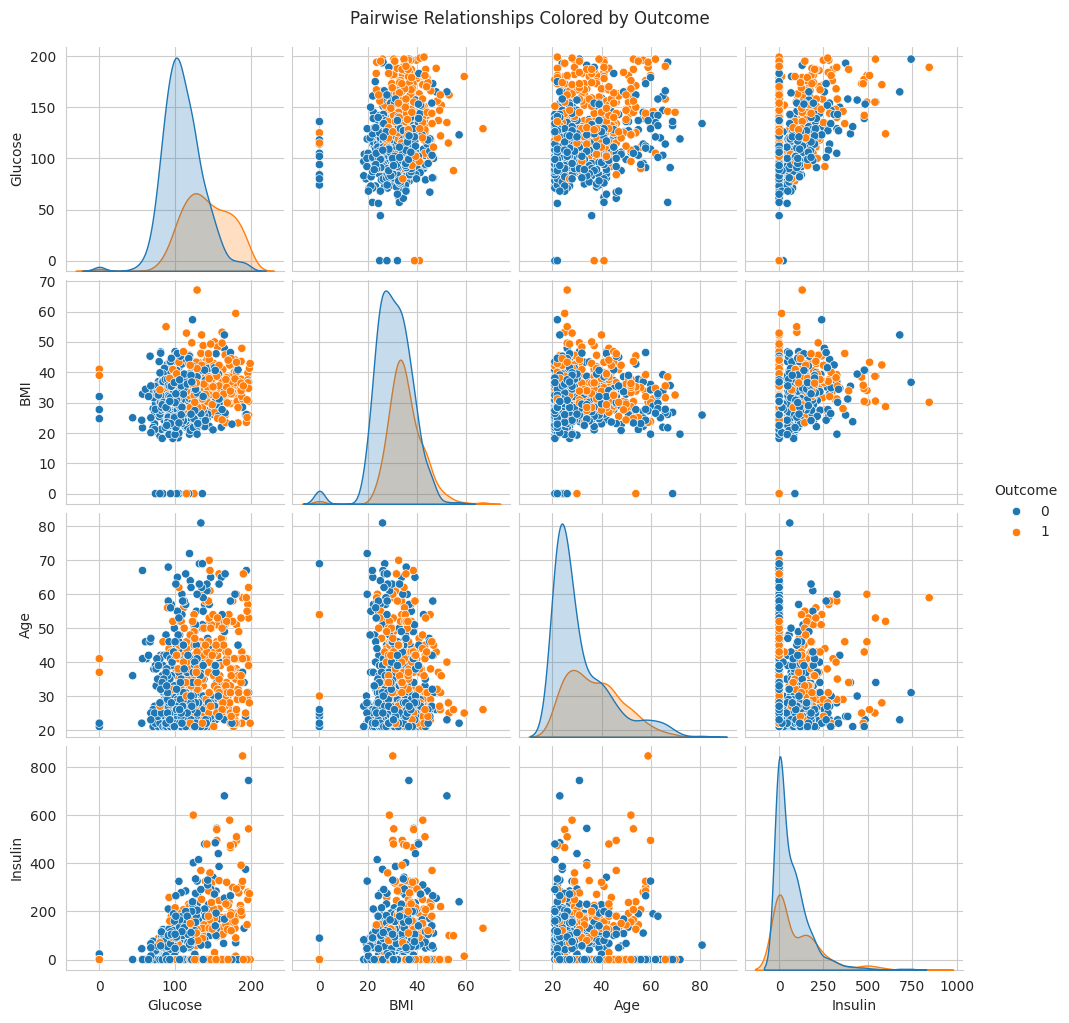

In [34]:
sns.pairplot(df, hue='Outcome', vars=['Glucose', 'BMI', 'Age', 'Insulin'], diag_kind='kde')
plt.suptitle('Pairwise Relationships Colored by Outcome', y=1.02)
plt.show()


## 4. Data Cleaning & Validation

In this dataset, a value of **0** in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, or `BMI` is not biologically possible — it actually means the value was **missing** when the data was recorded. We replace these zeros with `NaN` and then impute them (median for most columns, since they can be skewed by outliers).


In [35]:
print("Missing values per column (before cleaning):")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

zero_as_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nInvalid zero values per column:")
print((df[zero_as_missing_cols] == 0).sum())


Missing values per column (before cleaning):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0

Invalid zero values per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [37]:
# Replace biologically invalid zeros with NaN, then impute with the median
df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

print("Missing values after marking zeros as NaN:")
print(df_clean[zero_as_missing_cols].isnull().sum())

for col in zero_as_missing_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nMissing values after imputation:", df_clean.isnull().sum().sum())

df = df_clean
print("\nDataset is clean and ready for modeling.")


Missing values after marking zeros as NaN:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after imputation: 0

Dataset is clean and ready for modeling.


## 5. Feature Scaling & Train-Test Split


In [38]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (614, 8)  Test shape: (154, 8)


## 6. Model Training

We'll train and compare several classification algorithms.


In [39]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=9),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {"accuracy": acc, "cv_accuracy": cv_score, "model": model, "y_pred": y_pred}
    print(f"{name:25s} | Test Accuracy: {acc:.4f} | CV Accuracy: {cv_score:.4f}")


Logistic Regression       | Test Accuracy: 0.7078 | CV Accuracy: 0.7818
Decision Tree             | Test Accuracy: 0.6818 | CV Accuracy: 0.6873
Random Forest             | Test Accuracy: 0.7403 | CV Accuracy: 0.7655
K-Nearest Neighbors       | Test Accuracy: 0.7403 | CV Accuracy: 0.7607
Support Vector Machine    | Test Accuracy: 0.7403 | CV Accuracy: 0.7688


## 7. Model Comparison


In [40]:
results_df = pd.DataFrame({
    name: [res["accuracy"], res["cv_accuracy"]] for name, res in results.items()
}, index=["Test Accuracy", "CV Accuracy"]).T.sort_values("Test Accuracy", ascending=False)

results_df


,Test Accuracy,CV Accuracy
Random Forest,0.740260,0.765534
Support Vector Machine,0.740260,0.768759
K-Nearest Neighbors,0.740260,0.760656
Logistic Regression,0.707792,0.781794
Decision Tree,0.681818,0.687312


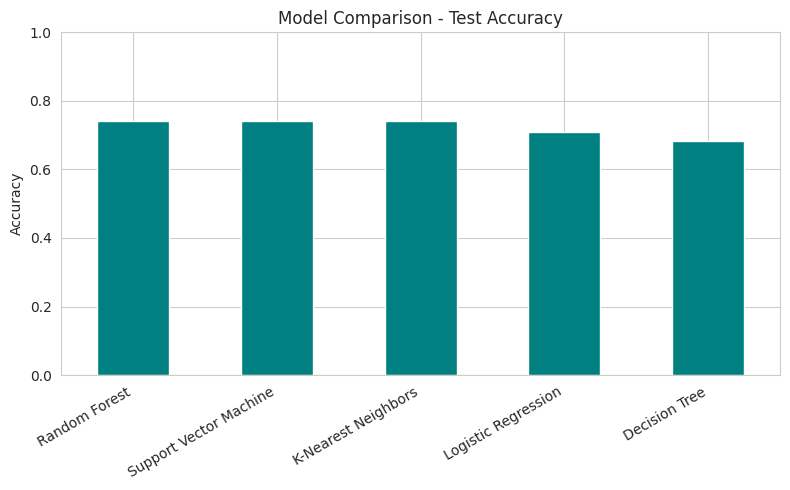

In [41]:
results_df["Test Accuracy"].plot(kind='bar', figsize=(8,5), color='teal')
plt.title('Model Comparison - Test Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 8. Detailed Evaluation of the Best Model


Best Model: Random Forest

Confusion Matrix:


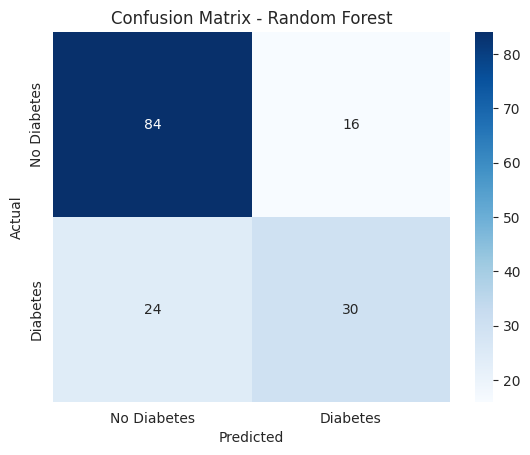


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [44]:
best_model_name = results_df["Test Accuracy"].idxmax()
best_model = results[best_model_name]["model"]
best_pred = results[best_model_name]["y_pred"]

print(f"Best Model: {best_model_name}\n")
print("Confusion Matrix:")
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, best_pred))


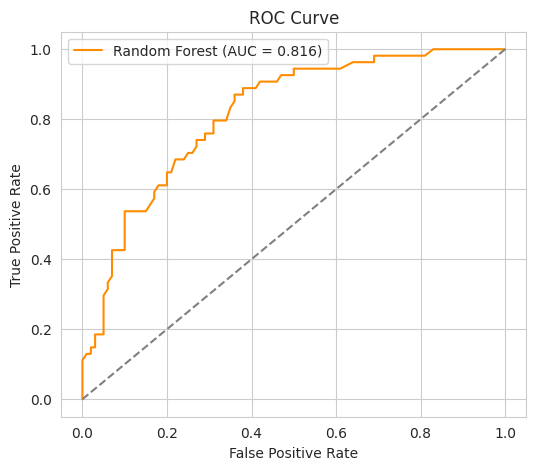

In [45]:
# ROC Curve
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.3f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## 9. Feature Importance (Random Forest)


/tmp/ipykernel_833/2500959342.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


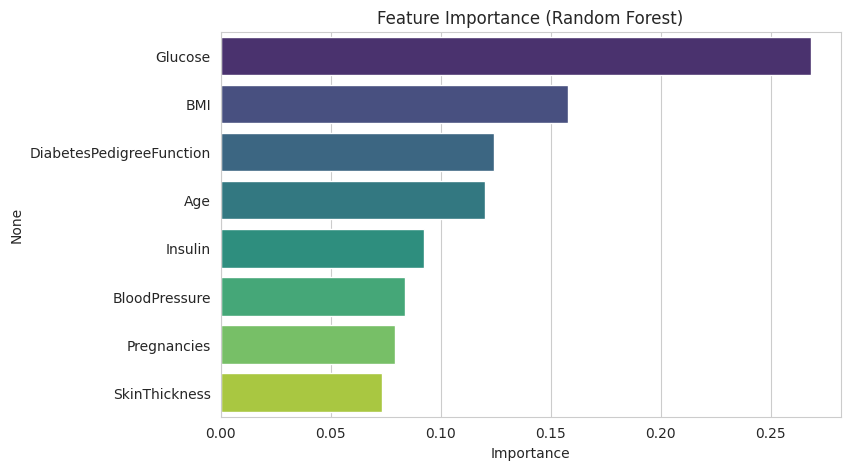

,0
Glucose,0.268355
BMI,0.158066
DiabetesPedigreeFunction,0.124386
Age,0.120345
Insulin,0.092340
BloodPressure,0.083938
Pregnancies,0.079370
SkinThickness,0.073200


In [46]:
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

importances


## 10. Hyperparameter Tuning (GridSearchCV)

Let's try to squeeze out better performance from Random Forest using grid search over key hyperparameters.


In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

tuned_rf = grid_search.best_estimator_
tuned_pred = tuned_rf.predict(X_test_scaled)
print("Tuned Random Forest Test Accuracy:", accuracy_score(y_test, tuned_pred))


Best Parameters: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Accuracy: 0.776915900306544
Tuned Random Forest Test Accuracy: 0.7402597402597403


## 11. XGBoost Classifier

XGBoost is a widely-used gradient boosting algorithm known for strong performance on tabular data like this.


In [43]:
!pip install xgboost -q
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                           eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Test Accuracy: {xgb_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))


XGBoost Test Accuracy: 0.7468

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



## 12. Saving the Final Model

We save the best model and the scaler so they can be reused later (e.g., in a Flask/Streamlit app) without retraining.


In [47]:
import joblib

joblib.dump(best_model, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved as 'diabetes_model.pkl' and 'scaler.pkl'")

# To reload later:
# loaded_model = joblib.load('diabetes_model.pkl')
# loaded_scaler = joblib.load('scaler.pkl')


Model and scaler saved as 'diabetes_model.pkl' and 'scaler.pkl'


## 13. Predicting on a New Patient (Sample Use Case)


In [48]:
# Example: predict diabetes for a new patient
# Column order: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI,
#               DiabetesPedigreeFunction, Age
sample_patient = np.array([[2, 130, 70, 30, 100, 32.5, 0.45, 35]])
sample_scaled = scaler.transform(sample_patient)

prediction = best_model.predict(sample_scaled)[0]
probability = best_model.predict_proba(sample_scaled)[0][1]

print(f"Prediction: {'Diabetic' if prediction == 1 else 'Not Diabetic'}")
print(f"Probability of diabetes: {probability:.2%}")


Prediction: Not Diabetic
Probability of diabetes: 41.50%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
